**Thiết lập môi trường**

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import dataclasses
from typing import Dict, Any

sys.path.append(os.path.dirname(os.getcwd()))

from app import data_store
from app.schemas.schedule_request import ScheduleRequest
from app.ga.scheduler import GAScheduler
from app.ga.fitness import evaluate_all_constraints
from app.ga.selection import pick_selection_method
from app.ga.elitism import get_elites
from app.ga.crossover import crossover_population
from app.ga.mutation import mutate_population
from app.ga.stopping import StoppingCondition
from app.schemas import Chromosome

In [2]:
class TrackedGAScheduler(GAScheduler):
    """
    Kế thừa GAScheduler để theo dõi lịch sử fitness và vi phạm ràng buộc qua từng thế hệ.
    """

    def run_tracked(self) -> Dict[str, Any]:
        self.initialize()

        self.stopping = StoppingCondition(
            max_generations=self.ga_cfg.max_generations,
            target_fitness=self.ga_cfg.target_fitness,
            max_time_seconds=self.ga_cfg.max_time_seconds,
            max_stall_generations=self.ga_cfg.max_stall_generations,
            base_mutation_rate=self.mut_cfg.rate,
            max_mutation_rate=min(1.0, self.mut_cfg.rate * 5),
        )
        self.stopping.reset()

        self.evaluate(self.population)

        history = {
            "generations": [],
            "best_fitness": [],
            "avg_fitness": [],
            "avg_hard_violations": [],
            "avg_soft_violations": [],
        }

        for generation in range(self.ga_cfg.max_generations):
            # Thu thập thống kê quần thể
            fv_list = []
            hv_list = []
            sv_list = []

            for chrom in self.population:
                fv = chrom.fitness
                h_c, _, s_c, _ = evaluate_all_constraints(
                    chrom,
                    self.courses_dict,
                    self.lecturers_dict,
                    self.rooms_dict,
                    self.timeslots_dict,
                )
                hv = sum(h_c.values())
                sv = sum(s_c.values())

                # Chuẩn hóa fitness cho mục đích vẽ biểu đồ (đặc biệt cho lexicographic)
                if isinstance(fv, tuple):
                    val = 1000 / (1 + hv) + sv
                else:
                    val = fv

                fv_list.append(val)
                hv_list.append(hv)
                sv_list.append(sv)

            current_best_idx = np.argmax(fv_list)
            history["generations"].append(generation)
            history["best_fitness"].append(fv_list[current_best_idx])
            history["avg_fitness"].append(np.mean(fv_list))
            history["avg_hard_violations"].append(np.mean(hv_list))
            history["avg_soft_violations"].append(np.mean(sv_list))

            # Các bước giải thuật di truyền
            current_best = self.population[current_best_idx]
            current_best_fitness = self.population[current_best_idx].fitness

            if self.best_chromosome is None or current_best_fitness > self.best_fitness:
                self.best_fitness = current_best_fitness
                self.best_chromosome = Chromosome(
                    genes=[dataclasses.replace(g) for g in current_best.genes],
                    fitness=current_best.fitness,
                )

            scalar_best = fv_list[current_best_idx]
            should_stop, _ = self.stopping.check_stop_and_adapt(
                generation, float(scalar_best)
            )
            if should_stop:
                break

            elites = get_elites(self.population, self.ga_cfg.elitism_rate)
            num_parents = self.ga_cfg.pop_size - len(elites)
            parents = pick_selection_method(
                self.population,
                num_parents,
                self.sel_cfg.method,
                self.sel_cfg.tournament_k,
            )
            offspring = crossover_population(
                parents,
                self.cross_cfg.method,
                self.cross_cfg.rate,
                self.cross_cfg.n_points,
            )
            offspring = mutate_population(
                offspring,
                list(self.lecturers_dict.values()),
                list(self.rooms_dict.values()),
                list(self.timeslots_dict.values()),
                method=self.mut_cfg.method,
                mutation_rate=self.stopping.current_mutation_rate,
                courses_dict=self.courses_dict,
                lecturers_dict=self.lecturers_dict,
                rooms_dict=self.rooms_dict,
                timeslots_dict=self.timeslots_dict,
            )
            self.evaluate(offspring)
            self.population = elites + offspring

        return history

In [3]:
def plot_convergence(hist):
    plt.figure(figsize=(10, 6))
    plt.plot(
        hist["generations"],
        hist["best_fitness"],
        label="Fitness tốt nhất (Best)",
        color="blue",
        linewidth=2,
    )
    plt.plot(
        hist["generations"],
        hist["avg_fitness"],
        label="Fitness trung bình (Average)",
        color="orange",
        linestyle="--",
    )
    plt.title(
        "Quá trình Hội tụ của Quần thể (Convergence Dynamics)", fontsize=14, pad=15
    )
    plt.xlabel("Thế hệ (Generation)", fontsize=12)
    plt.ylabel("Giá trị Fitness", fontsize=12)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.show()
    plt.close()


def plot_hard_soft_tradeoff(hist):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    plt.title(
        "Phân tích Đánh đổi Ràng buộc Cứng và Mềm (Trade-off Analysis)",
        fontsize=14,
        pad=15,
    )
    ax1.set_xlabel("Thế hệ (Generation)", fontsize=12)
    ax1.set_ylabel("Trung bình Vi phạm Ràng buộc Cứng", color="red", fontsize=12)
    ax1.plot(
        hist["generations"],
        hist["avg_hard_violations"],
        color="red",
        label="Lỗi Ràng buộc Cứng",
        linewidth=2,
    )
    ax1.tick_params(axis="y", labelcolor="red")
    ax2 = ax1.twinx()
    ax2.set_ylabel("Trung bình Điểm Ràng buộc Mềm", color="blue", fontsize=12)
    ax2.plot(
        hist["generations"],
        hist["avg_soft_violations"],
        color="blue",
        label="Điểm Ràng buộc Mềm",
        linestyle="--",
    )
    ax2.tick_params(axis="y", labelcolor="blue")
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.show()
    plt.close()

In [4]:
data_store.init()
MAX_GEN = 200

print("Bắt đầu thí nghiệm với Weighted Fitness...")
req1 = ScheduleRequest()
req1.fitness.method = "weighted"
req1.mutation.method = "heuristic"
req1.ga.pop_size = 100
req1.ga.max_generations = MAX_GEN
hist1 = TrackedGAScheduler(req1).run_tracked()

print("Bắt đầu thí nghiệm với Alpha-Beta Fitness...")
req2 = ScheduleRequest()
req2.fitness.method = "alpha_beta"
req2.mutation.method = "heuristic"
req2.ga.pop_size = 100
req2.ga.max_generations = MAX_GEN
hist2 = TrackedGAScheduler(req2).run_tracked()

print("Bắt đầu thí nghiệm với Penalty Fitness...")
req3 = ScheduleRequest()
req3.fitness.method = "penalty"
req3.mutation.method = "heuristic"
req3.ga.pop_size = 100
req3.ga.max_generations = MAX_GEN
hist3 = TrackedGAScheduler(req3).run_tracked()

print("Bắt đầu thí nghiệm với Lexicographic Fitness...")
req4 = ScheduleRequest()
req4.fitness.method = "lexicographic"
req4.mutation.method = "heuristic"
req4.ga.pop_size = 100
req4.ga.max_generations = MAX_GEN
hist4 = TrackedGAScheduler(req4).run_tracked()

Bắt đầu thí nghiệm với Weighted Fitness...
=== SESSIONS ===
course: CT101-M01 | session: 1 | units: 3
course: CT101-M01 | session: 2 | units: 3
course: CT101-M01 | session: 3 | units: 3
course: CT101-M02 | session: 1 | units: 3
course: CT101-M02 | session: 2 | units: 3
course: CT101-M02 | session: 3 | units: 3
course: CT200-M01 | session: 1 | units: 3
course: CT200-M01 | session: 2 | units: 3
course: CT200-M01 | session: 3 | units: 3
course: CT200-M01 | session: 4 | units: 3
course: CT200-M02 | session: 1 | units: 3
course: CT200-M02 | session: 2 | units: 3
course: CT200-M02 | session: 3 | units: 3
course: CT200-M02 | session: 4 | units: 3
course: CT102-M01 | session: 1 | units: 3
course: CT102-M01 | session: 2 | units: 3
course: CT102-M01 | session: 3 | units: 3
course: CT102-M01 | session: 4 | units: 3
course: CT102-M02 | session: 1 | units: 3
course: CT102-M02 | session: 2 | units: 3
course: CT102-M02 | session: 3 | units: 3
course: CT102-M02 | session: 4 | units: 3
course: CT239-M0

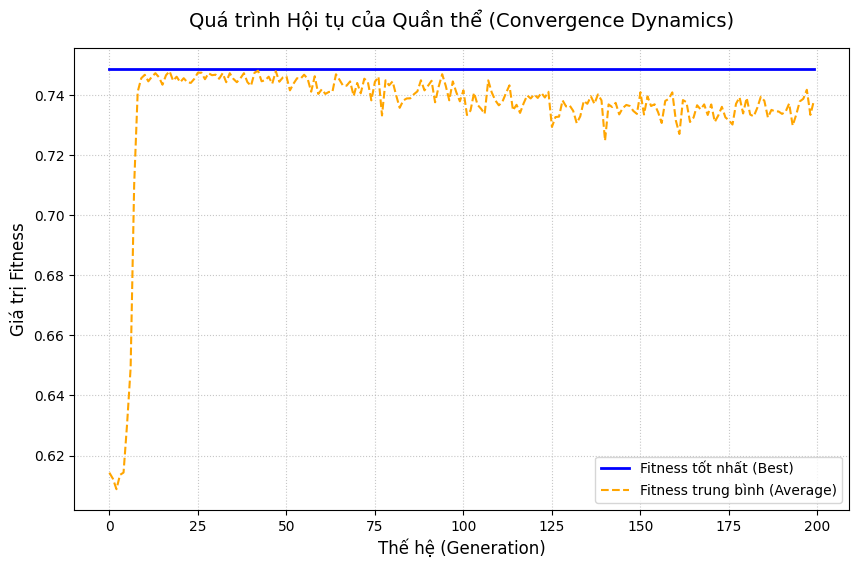

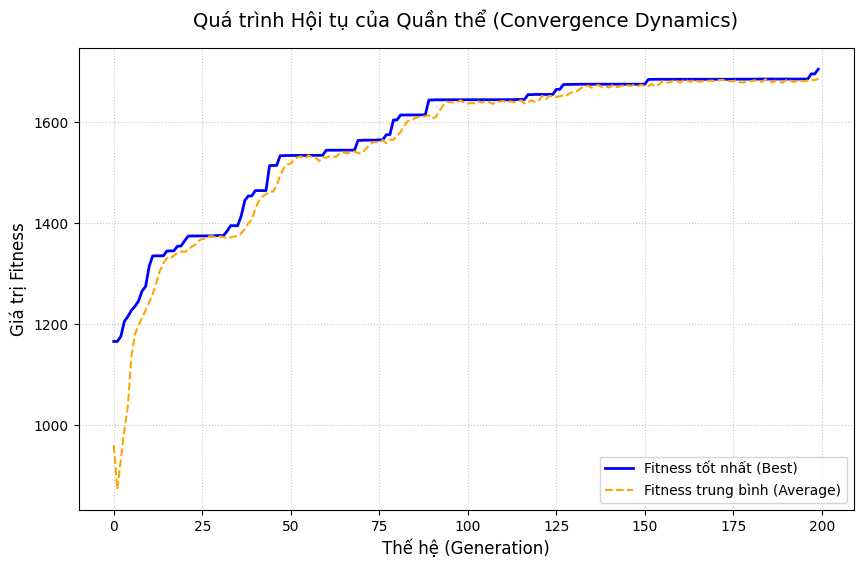

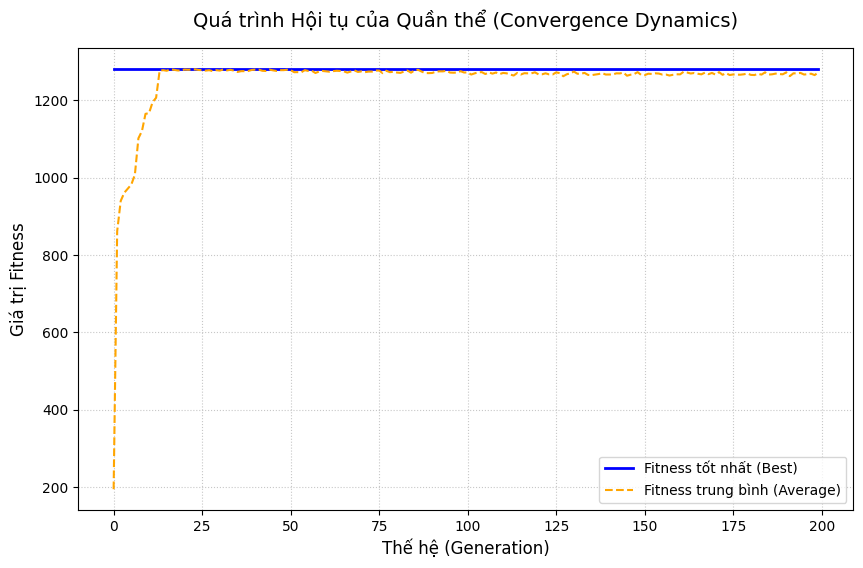

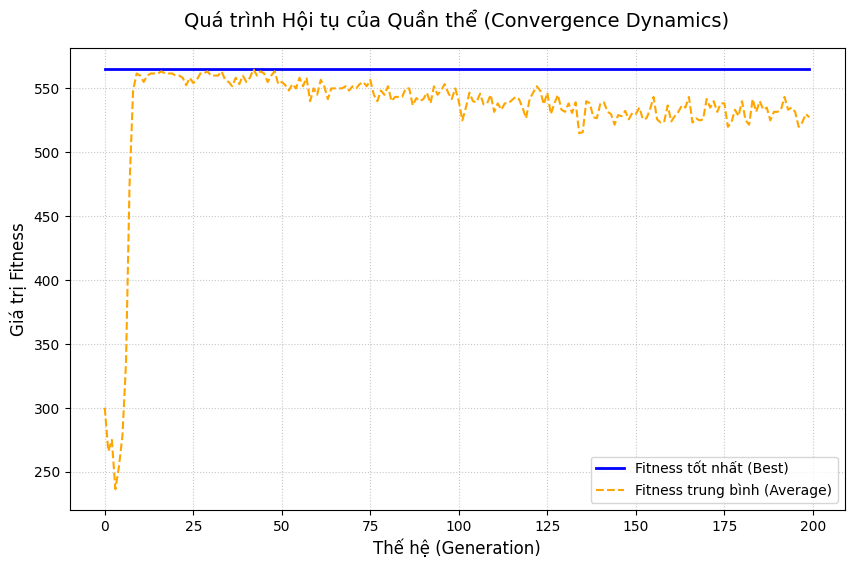

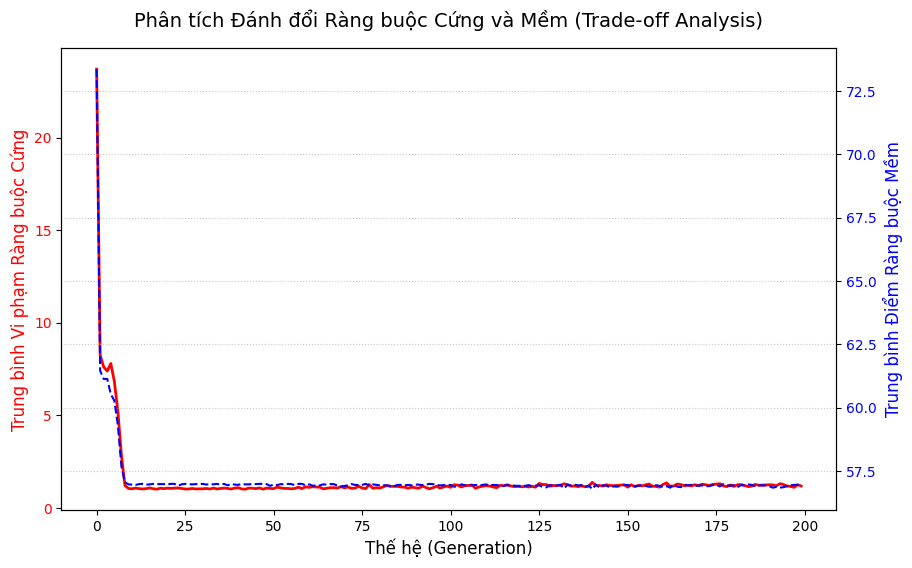

In [5]:
plot_convergence(hist1)
plot_convergence(hist2)
plot_convergence(hist3)
plot_convergence(hist4)
plot_hard_soft_tradeoff(hist1)